In [1]:
library(Seurat) 
#library(SeuratData)
library(ggplot2)
library(patchwork)
library(dplyr)

library(randomcoloR)
#library(harmony) #1.2.3
options(future.globals.maxSize = 8000 * 1024^2) #8G max, important!

Attaching SeuratObject

‘SeuratObject’ was built under R 4.3.1 but the current version is
4.3.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Warning message:
“package ‘patchwork’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
obj <- readRDS("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/Smooth/RDS/SeuratObj_gw16.rds")

obj = NormalizeData(obj) %>%
    FindVariableFeatures() %>%
    ScaleData() %>%
    RunPCA() %>%
    RunUMAP(dims = 1:15) %>%
    FindNeighbors(dims = 1:15) %>%
    FindClusters(resolution = 0.5)

obj$individual_clusters = paste0("C",obj$seurat_clusters)
obj$individual_clusters = factor(obj$individual_clusters,levels = paste0("C",0:5))

Centering and scaling data matrix

PC_ 1 
Positive:  COL3A1, COL1A2, COL1A1, HBG2, HBG1, HBA2, HBA1, GFAP, IGFBP5, PLP1 
	   MBP, HBB, CLDN5, PTN, SPP1, MAG, MPZ, TF, ACTA2, ENPP2 
	   MYLK, ITGA8, FAM210B, CCN4, HBM, EMILIN1, SYPL1, CARNS1, MIA, GLI3 
Negative:  STMN2, TUBB2A, TUBA1A, GAP43, NEFL, NEFM, SST, PENK, KCNIP4, PRRT2 
	   CADM2, SV2A, TAC1, NPY, CCK, ERBB4, KCND2, GPC5, OLFM3, NPPC 
	   PCDH15, KHDRBS2, DOC2A, AK1, EFNB3, C9orf24, SGCZ, UGCG, RNF175, GFOD1 
PC_ 2 
Positive:  HBG1, HBG2, HBA2, HBA1, HBB, COL1A2, COL3A1, COL1A1, IGFBP5, STMN2 
	   PTN, GAP43, CLDN5, TUBB2A, PENK, SST, NPY, PRRT2, KCNIP4, CCK 
	   NEFL, TAC1, NEFM, NPPC, ITGA8, SV2A, DOC2A, AP3S1, FAM210B, PDP1 
Negative:  MBP, PLP1, GFAP, MAG, TF, ENPP2, SPARCL1, CARNS1, BACE1, CENPF 
	   RSPH1, PDGFA, TMEM125, C9orf24, KIF9, SGCZ, FUBP3, FOXJ1, CAPS, AGTRAP 
	   STK38L, CFTR, ACBD7, AK1, TMEM88B, FEN1, SEMA5B, HAS2, SPP1, MBIP 
PC_ 3 
Positive:  C9orf24, CAPS, AK1, RSPH1, FOXJ1, PLP1, KIF9, FAM183A, MBP, EFN

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 21039
Number of edges: 635505

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8769
Number of communities: 24
Elapsed time: 2 seconds


In [3]:
#snMulti-omics data
snMulti_GW16 <- readRDS("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/rds/0.SeuratObj_GW16_raw.rds")
DefaultAssay(snMulti_GW16) <- "RNA"
snMulti_GW16

Loading required package: Signac

Signac built for for SeuratObject v4 was just loaded with SeuratObject
v5; disabling v5 assays and validation routines, and ensuring assays
work in strict v3/v4 compatibility mode



An object of class Seurat 
181062 features across 20000 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC

In [4]:
# Load the metadata table
mat = read.table("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/cluster.df.add.combine.add_annotation.txt", header = T, row.names = 1)
head(mat)

,cluster,UMAP_1,UMAP_2,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,percent.hb,percent.xist,⋯,UMAP1_2,sample1,barcode1,cluster2,UMAP2_1,UMAP2_2,sample2,sample_ori,barcode2,cell_name
,<int>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
AAACAGCCACCAAAGG-1_GW7,14,-0.9332416,3.3418352,spinalcord-GW6-RNA,2311,1379,0.08654262,1.774124,0.00000000,0,⋯,-0.4842752,GW7,AAACAGCCACCAAAGG-1,di1,6.430145,7.77638150,GW7,spinalcord-rna-GW6,AAACAGCCACCAAAGG-1,ExN_naive
AAACAGCCACGTAATT-1_GW7,0,-6.6697190,-4.7685805,spinalcord-GW6-RNA,6164,2595,0.00000000,2.855289,0.11356262,0,⋯,-7.3128411,GW7,AAACAGCCACGTAATT-1,di4_di6,9.653541,1.13760520,GW7,spinalcord-rna-GW6,AAACAGCCACGTAATT-1,v2a/b
AAACAGCCACTAAGCC-1_GW7,5,-4.3490484,-4.2296906,spinalcord-GW6-RNA,4239,1925,0.00000000,2.052371,0.00000000,0,⋯,-4.5203754,GW7,AAACAGCCACTAAGCC-1,p0_p1,12.722731,1.39139700,GW7,spinalcord-rna-GW6,AAACAGCCACTAAGCC-1,v0/1
AAACAGCCACTTACAG-1_GW7,34,12.9444234,0.1813366,spinalcord-GW6-RNA,1448,1050,0.00000000,3.867403,0.13812155,0,⋯,0.0116368,GW7,AAACAGCCACTTACAG-1,RP,10.919187,2.35317060,GW7,spinalcord-rna-GW6,AAACAGCCACTTACAG-1,RP
AAACAGCCAGATAGAC-1_GW7,24,-6.0747998,-5.4570985,spinalcord-GW6-RNA,3456,1857,0.00000000,3.906250,0.05787037,0,⋯,-6.4426528,GW7,AAACAGCCAGATAGAC-1,v0_v1,10.575561,0.06181687,GW7,spinalcord-rna-GW6,AAACAGCCAGATAGAC-1,InN_ventral_like
AAACAGCCAGCTTAGC-1_GW7,14,-0.1686835,3.1114461,spinalcord-GW6-RNA,1603,1092,0.00000000,2.869619,0.00000000,0,⋯,1.5368240,GW7,AAACAGCCAGCTTAGC-1,di1,7.195307,9.34262100,GW7,spinalcord-rna-GW6,AAACAGCCAGCTTAGC-1,ExN_naive


In [5]:
# First create a mapping dictionary
map_dict <- list(
  "AST_from_dIPC" = "AST",
  "COP" = "COP",
  "di2" = "ExN_immature_3",
  "dIPC" = "dIPC",
  "dorsal_glia" = "dorsal_glia",
  "Ependymal" = "Ependymal",
  "ExN_CCK+" = "ExN_mature_2",
  "ExN_CCK+_immature" = "ExN_immature_2",
  "ExN_major" = "ExN_mature_1",
  "ExN_major_immture" = "ExN_immature_1",
  "ExN_naive" = "ExN_naive",
  "ExN_SLIT1+" = "ExN_mature_3",
  "FP" = "FP",
  "InN_immature-1" = "InN_immature_1",
  "InN_immature-2" = "InN_immature_2",
  "InN_mature-1" = "InN_mature_1",
  "InN_mature-2" = "InN_mature_2",
  "InN_naive" = "InN_naive",
  "InN_ventral_like" = "InN_ventral_like",
  "MFOL" = "MFOL",
  "Microglia" = "Microglia",
  "MN1" = "MN1",
  "MN2" = "MN2",
  "MOL" = "MOL",
  "NPC" = "NPC",
  "NPC_proliferative" = "NPC_proliferative",
  "OPC" = "OPC",
  "OPC_new?" = "OPC",
  "RP" = "RP",
  "v0/1" = "v0_1",
  "v0/1-small" = "v0_1",
  "v2a/b" = "v2a_b",
  "ventral_glia" = "ventral_glia",
  "ventral_unknow" = "ventral_unknow",
  "vIPC_p0/1" = "vIPC"
)

# Create a new `celltype` column initialized from `cell_name`
mat$celltype <- mat$cell_name

# Update the `celltype` column based on the mapping dictionary
mat$celltype <- sapply(mat$cell_name, function(x) {
  if (x %in% names(map_dict)) {
    return(map_dict[[x]])
  } else {
    return(x)  # Keep the original value if no mapping is found
  }
})

In [6]:
mat = mat[mat$sample_new == "GW16", c('UMAP_1', 'UMAP_2', 'sample_new', 'cluster2', 'UMAP2_1', 'UMAP2_2', 'barcode2', 'celltype')]
rownames(mat) <- mat$barcode2

In [7]:
# Keep the cells that satisfy the selection criteria
rna <- subset(snMulti_GW16, cells = mat$barcode2)
# Merge `mat` into `meta.data`
rna@meta.data <- cbind(rna@meta.data, mat)
umap_coords <- rna@meta.data[, c("UMAP2_1", "UMAP2_2")]
umap_coords <- as.matrix(umap_coords)
colnames(umap_coords) <- c("UMAP_1", "UMAP_2")
rna@reductions$umap <- CreateDimReducObject(
    embeddings = umap_coords,
    key = "UMAP_",  # Standard Seurat UMAP key name
    assay = "RNA"   # Specify the associated assay
  )
rna

An object of class Seurat 
181062 features across 14273 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC
 1 dimensional reduction calculated: umap

In [8]:
obj$dataset = "spatial"
rna$dataset = "rna"
#----------merge
combined = merge(obj,rna)

# split the dataset into a list of two seurat objects (stim and CTRL)
obj.list <- SplitObject(combined, split.by = "dataset")
obj.list <- lapply(X = obj.list, FUN = SCTransform)
features <- SelectIntegrationFeatures(object.list = obj.list, nfeatures = 3000)
obj.list <- PrepSCTIntegration(object.list = obj.list, anchor.features = features)
obj.list <- lapply(X = obj.list, FUN = RunPCA, features = features)

anchors <- FindIntegrationAnchors(object.list = obj.list, normalization.method = "SCT",
                                  anchor.features = features, dims = 1:30, reduction = "cca", k.anchor = 20)
combined_sct <- IntegrateData(anchorset = anchors, normalization.method = "SCT", dims = 1:30)

# library(harmony)
# combined_sct <- RunPCA(combined_sct, verbose = FALSE)
# combined_sct = RunHarmony(combined_sct, 
#                           group.by.vars = "dataset", 
#                           reduction = "pca", dims.use = 1:20, 
#                           assay.use = "integrated", 
#                           project.dim = F,
#                           verbocombined = T,
#                           reduction.save = "harmony") %>%
#   RunUMAP(reduction = "harmony", dims = 1:20)%>%
#   FindNeighbors(reduction = 'harmony', dims = 1:20) %>%
#   FindClusters() 

#without harmony
combined_sct <- RunPCA(combined_sct, verbose = FALSE) %>%
                  RunUMAP(dims = 1:30)%>%
                  FindNeighbors(dims = 1:30) %>%
                  FindClusters(resolution = 1.0) 

ATAC assay doesn't leave any cells, so it is removed

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 20995 by 21039

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells



  |======================================================================| 100%


Found 2 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 20995 genes



  |======================================================================| 100%


Computing corrected count matrix for 20995 genes



...

Computing corrected count matrix for 25060 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 3.171442 mins

Determine variable features

Place corrected count matrix in counts slot

Centering data matrix

Set default assay to SCT

PC_ 1 
Positive:  STMN2, MT-ND1, CST3, NEFM, SNHG14, SST, GPM6A, MBP, SPARCL1, CNTN1 
	   PLP1, LSAMP, PCDH9, CELF4, SCRG1, RBFOX1, NRXN1, CADM2, KCNIP4, CNTNAP2 
	   ROBO2, PTPRZ1, OLIG1, GRID2, PCDH7, ELAVL2, GRIA2, PTPRD, NLGN1, NCAM2 
Negative:  HBG2, HBA2, HBG1, HBA1, HBB, COL1A2, COL3A1, COL1A1, IGF2, IGFBP5 
	   DCN, ITM2A, PTGDS, COL18A1, CLDN5, PTN, ALAS2, HBM, VIM, PCOLCE 
	   CXCL12, LGALS1, EXOSC7, OGN, LRRC17, CYP1B1, ITIH2, LAMA2, POSTN, VAMP5 
PC_ 2 
Positive:  HBG2, HBG1, HBA2, HBA1, STMN2, HBB, MT-ND1, CST3, NEFM, SNHG14 
	   GPM6A, SST, CADM2, RBFOX1, NRXN1, ROBO2, KCNIP4, CELF4, CNTNAP2, LSAMP 
	   PCDH9, PENK, MBP, DLG2, EBF3, NCAM2, PTPRZ1, CNTN1, PTPRD, NOVA1 
Negative:  COL3A1, COL1A2, COL1A1, IGF2, IGFBP5, DCN, PTGDS, COL18A1, PTN, VIM 
	   PCOLCE, CYP1B1, FMOD

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 35312
Number of edges: 1336988

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8504
Number of communities: 24
Elapsed time: 8 seconds


1 singletons identified. 23 final clusters.



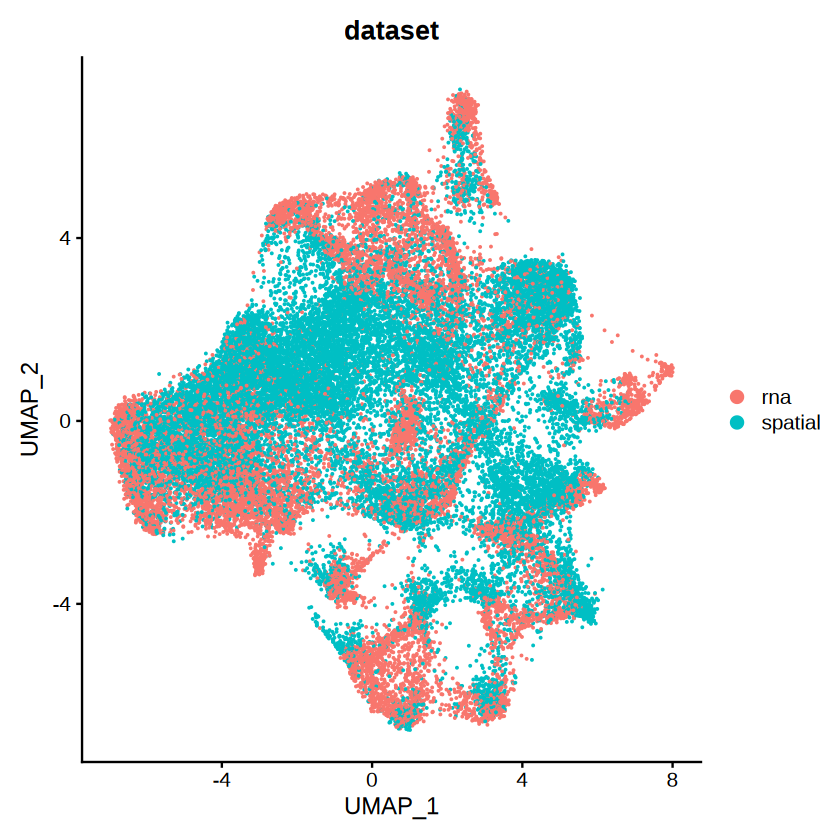

In [9]:
DimPlot(combined_sct, reduction = "umap", group.by = "dataset",  raster=FALSE, shuffle = TRUE)

In [10]:
#---Find neighbors
#k.neighbor = 100
#dims = 1:20
#combined_sct = Seurat::FindNeighbors(combined_sct, 
#                                                k.param = k.neighbor,
#                                                reduction="harmony",
#                                                dims=dims, 
#                                                return.neighbor = T, 
#                                                assay = "integrated")

k.neighbor = 100
dims = 1:30#1:10
combined_sct = Seurat::FindNeighbors(combined_sct, 
                                     k.param = k.neighbor,
                                     #reduction="harmony",
                                     reduction="pca",
                                     dims=dims, 
                                     return.neighbor = T, #must set TRUE, or neighbor slot will be empty?
                                     assay = "integrated"
                                    )

combined_scRNA = suppressWarnings(subset(combined_sct, subset = dataset == "rna"))
combined_spatial = suppressWarnings(subset(combined_sct, subset = dataset == "spatial"))
cells_scrna = colnames(combined_scRNA)
cells_spatial = colnames(combined_spatial)
neigbors = suppressWarnings(sapply(cells_spatial, function(i){
    Seurat::TopNeighbors(combined_sct@neighbors$integrated.nn, i, n = k.neighbor)
}))
neigbors = as.data.frame(neigbors)
neigbors = as.list(neigbors)
#---only select neighbor in scRNA data
neigbors_scRNA = lapply(neigbors, function(x){
    x = x[x %in% cells_scrna]
})
#---------------------------------------hormany/no harmony
min(sapply(neigbors_scRNA, length))         #0/0
max(sapply(neigbors_scRNA, length))         #99/49
sum(sapply(neigbors_scRNA, length) == 0)    #0/69
sum(sapply(neigbors_scRNA, length) == 1)    #0/58
sum(sapply(neigbors_scRNA, length) == 2)    #0/72
sum(sapply(neigbors_scRNA, length) > 10)    #3682/1575
sum(sapply(neigbors_scRNA, length) < 10)    #0/593

Computing nearest neighbors



Only one graph name supplied, storing nearest-neighbor graph only

ATAC assay doesn't leave any cells, so it is removed



[1] 0

[1] 99

[1] 3954

[1] 3234

[1] 2290

[1] 4669

[1] 15969

In [11]:
##pairing
nn.idx <- combined_sct@neighbors$integrated.nn@nn.idx#18647 x 100 matrix
nn.dist <- combined_sct@neighbors$integrated.nn@nn.dist#18647 x 100
nn.cellid <- combined_sct@neighbors$integrated.nn@cell.names #18647
idx.st <- which(colnames(obj) %in% nn.cellid)
nn.idx.st <- nn.idx[idx.st,]
nn.dist.st <- nn.dist[idx.st,]
nn.cellid.st <- nn.cellid[idx.st]
#translate idx to cellid
nn.idx.name <- apply(X = nn.idx, FUN = function(x){nn.cellid[x]}, MARGIN = 1) 

res.paired.all <- data.frame()
targetid.list <- list()
cells_scrna = colnames(combined_scRNA)

In [12]:
neighbor_counts <- numeric(length(idx.st))

for (k in seq_along(idx.st)) {
    i <- idx.st[k]  
    nn.idx.row1 <- nn.idx[i,] 
    nn.idx.name.row1 <- nn.cellid[nn.idx.row1]
    nn.dist.row1 <- nn.dist[i,]

    res.row1 <- data.frame(nn.idx.row1 = nn.idx.row1, 
                           nn.idx.name.row1 = nn.idx.name.row1, 
                           nn.dist.row1  = nn.dist.row1)

    res.row1.order <- res.row1[order(res.row1$nn.dist.row1),]  
    res.row1.filter <- res.row1.order[res.row1.order$nn.idx.name.row1 %in% cells_scrna,]  # only keep scRNA neighbors

    # number
    neighbor_counts[k] <- nrow(res.row1.filter)
}

# sort
sorted_idx <- idx.st[order(neighbor_counts)]

In [13]:
for(i in sorted_idx){
    # for each cell in spatial
    nn.idx.row1 <-  nn.idx[i,] #id (1-number of st cells)
    nn.idx.name.row1 <- nn.cellid[nn.idx.row1] #barcodes
    nn.dist.row1 <- nn.dist[i,] # first is itself

    res.row1 <- data.frame(nn.idx.row1 = nn.idx.row1, nn.idx.name.row1 = nn.idx.name.row1,nn.dist.row1  = nn.dist.row1 )

    ##already sorted, but sort anyway
    res.row1.head1 <- res.row1[1,]
    res.row1 <- res.row1[-1,]
    res.row1.order <- res.row1[order(res.row1$nn.dist.row1),]

    stopifnot(all.equal(res.row1,res.row1.order))#TRUE

    res.row1.filter <- res.row1.order[res.row1.order$nn.idx.name.row1 %in% cells_scrna,] #only keep scRNA neighbors

    #stopifnot(nrow(res.row1.filter)!=0)
    if(nrow(res.row1.filter) == 0){cat('warning: row ',i,' found 0 target, skip \n',sep='');next}
    #choose the non-redundant one

    res.paired <- data.frame()

    for(j in 1:nrow(res.row1.filter)){
        
        res.row1.filter.head1 <- res.row1.filter[j,] # first rna cell
        
        if( is.null(targetid.list[[res.row1.filter.head1$nn.idx.name.row1]]) ){ 
            #if not exists, combine to result df, exit for loop
            res.paired <- data.frame(idx1=res.row1.head1$nn.idx.row1,
                                id1=res.row1.head1$nn.idx.name.row1, # barcode
                                idx2=res.row1.filter.head1$nn.idx.row1,
                                id2=res.row1.filter.head1$nn.idx.name.row1, # barcode
                                dist = res.row1.filter.head1$nn.dist.row1
                            )
            
            targetid.list[[res.row1.filter.head1$nn.idx.name.row1]] <- 1
            cat(file='log.find_nonredundancy_nearest_neghbor_within100','row',i,' iterates as j ',j,' to find non-redundancy row, with dist row1: ',res.row1.filter[1,3],' to dist rowj: ',res.row1.filter[j,3], '\n',sep='',append = TRUE)
            break
        }else{
            #or use next row
            targetid.list[[res.row1.filter.head1$nn.idx.name.row1]] <- targetid.list[[res.row1.filter.head1$nn.idx.name.row1]] + 1
            next
        }
    }

    if(nrow(res.paired) !=1){cat(file='log.find_nonredundancy_nearest_neghbor_within100','row',i,' is empty after check redundancy\n',sep='',append = TRUE) }
    res.paired.all <- rbind.data.frame(res.paired.all,res.paired)
}

In [14]:
##get cluster.df.add.st
obj[['cluster_integration']] <- Idents(combined_spatial)
cluster <- obj[['individual_clusters']] #Idents(obj.st)
umap <- obj@reductions$umap@cell.embeddings
cluster.df <- data.frame(cluster=cluster,umap)
colnames(cluster.df) <- c('cluster_st','umap1_st','umap2_st')
metadata <- obj@meta.data
cluster.df.add.st <- cbind(cluster.df, metadata)

##get cluster.df.add.rna
rna[['cluster_integration']] <- Idents(combined_scRNA)
cluster <- rna[['celltype']] #Idents(obj.rna)
umap <- rna@reductions$umap@cell.embeddings
cluster.df <- data.frame(cluster=cluster,umap)
colnames(cluster.df) <- c('cluster_rna','umap1_rna','umap2_rna')
metadata <- rna@meta.data
cluster.df.add.rna <- cbind(cluster.df, metadata)

##get cluster.df.add.int
cluster <- Idents(combined_sct)
umap <- Embeddings(combined_sct, reduction = 'umap')
cluster.df <- data.frame(cluster=cluster, umap)
colnames(cluster.df) <- c('cluster_int','umap1_int','umap2_int')
metadata <- combined_sct@meta.data
cluster.df.add.int <- cbind(cluster.df, metadata)


In [15]:
##combine to paired cluster.df.add
cluster.df.add <- cbind( id_st = res.paired.all$id1, 
                              cluster.df.add.st[res.paired.all$id1,c('cluster_st','umap1_st','umap2_st','x','y','cluster_integration')],
                             cluster.df.add.int[res.paired.all$id1,c('cluster_int','umap1_int','umap2_int')],
                             id_rna = res.paired.all$id2,
                             cluster.df.add.rna[res.paired.all$id2,c('cluster_rna','umap1_rna','umap2_rna','cluster_integration')],
                             cluster.df.add.int[res.paired.all$id2,c('cluster_int','umap1_int','umap2_int')],
                            
                            dist = res.paired.all$dist
                            )

colnames(cluster.df.add) <- c('id_st','cluster_st','umap1_st','umap2_st','x_st','y_st','cluster_integration_st','cluster_int_st','umap1_int_st','umap2_int_st','id_rna','cluster_rna','umap1_rna','umap2_rna','cluster_integration_rna','cluster_int_rna','umap1_int_rna','umap2_int_rna','dist')

In [16]:
write.csv(cluster.df.add, file = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/cluster_df_add.csv", row.names = FALSE)

In [17]:
head(cluster.df.add)

,id_st,cluster_st,umap1_st,umap2_st,x_st,y_st,cluster_integration_st,cluster_int_st,umap1_int_st,umap2_int_st,id_rna,cluster_rna,umap1_rna,umap2_rna,cluster_integration_rna,cluster_int_rna,umap1_int_rna,umap2_int_rna,dist
,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
GW16:16980_9060,GW16:16980_9060,NA,0.4290586,-0.5339778,16980,9060,12,12,6.037286,0.1400448,CAATCTAAGTGATTCA-1,ExN_naive,7.361134,9.776201,6,6,-1.547803,-0.3937994,5.567631
GW16:13920_10980,GW16:13920_10980,NA,3.7931748,-3.7004668,13920,10980,8,8,3.620434,-2.1977029,CTCTGTTCAGCGCTTG-1,ExN_immature_2,6.880278,12.010080,3,3,-1.211892,0.6668509,5.019492
GW16:14460_8220,GW16:14460_8220,NA,-1.2409007,-2.5285661,14460,8220,5,5,-4.292943,0.6377883,ACTTACTTCTGTTCAT-1,ExN_naive,7.416456,10.244309,5,5,-4.512519,1.0370989,3.098650
GW16:15810_11850,GW16:15810_11850,NA,1.5022418,1.8924631,15810,11850,12,12,4.461350,0.4660424,GCAGGCAAGAGAAGGG-1,InN_naive,11.300057,8.378053,12,12,4.749775,0.4619060,6.310985
GW16:13740_7980,GW16:13740_7980,NA,-1.1740619,-3.8913381,13740,7980,5,5,-4.178096,1.1218636,GAGTGTTTCCTAGTCC-1,ExN_immature_1,8.168856,11.156652,5,5,-4.018761,1.0226429,3.733243
GW16:15960_9420,GW16:15960_9420,NA,-1.3421488,-4.5164909,15960,9420,3,3,-1.660416,1.3538055,GGATTGCGTCCAAGAC-1,InN_mature_1,6.864603,7.447139,3,3,-3.327302,0.1627104,3.202048


In [18]:
ls()

[1] "anchors"               "cells_scrna"           "cells_spatial"        
 [4] "cluster"               "cluster.df"            "cluster.df.add"       
 [7] "cluster.df.add.int"    "cluster.df.add.rna"    "cluster.df.add.st"    
[10] "combined"              "combined_scRNA"        "combined_sct"         
[13] "combined_spatial"      "dims"                  "features"             
[16] "i"                     "idx.st"                "j"                    
[19] "k"                     "k.neighbor"            "map_dict"             
[22] "mat"                   "metadata"              "neigbors"             
[25] "neigbors_scRNA"        "neighbor_counts"       "nn.cellid"            
[28] "nn.cellid.st"          "nn.dist"               "nn.dist.row1"         
[31] "nn.dist.st"            "nn.idx"                "nn.idx.name"          
[34] "nn.idx.name.row1"      "nn.idx.row1"           "nn.idx.st"            
[37] "obj"                   "obj.list"              "res.paired"           
[40] "res.paired.all"        "res.row1"              "res.row1.filter"      
[43] "res.row1.filter.head1" "res.row1.head1"        "res.row1.order"       
[46] "rna"                   "snMulti_GW16"          "sorted_idx"           
[49] "targetid.list"         "umap"                  "umap_coords"

In [19]:
# rna umap matrix
rna_umap <- rna@reductions$umap@cell.embeddings
write.csv(rna_umap, file = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/rna_umap.csv", row.names = TRUE)

In [20]:
cod = obj@meta.data[,c("x","y")]
colnames(cod) <- c("cod1", "cod2") 
write.csv(cod, file = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/spatial_coord.csv", row.names = TRUE)

In [21]:
rna_anno <- rna@meta.data['celltype']
write.csv(rna_anno, file = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/rna_anno.csv", row.names = TRUE)

In [22]:
link_st_matrix <- cluster.df.add[, c("id_st", "id_rna", "cluster_rna")]
write.csv(link_st_matrix, file = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/multimapping/GW16/link_st_matrix.csv", row.names = FALSE)

In [23]:
head(link_st_matrix)

,id_st,id_rna,cluster_rna
,<chr>,<chr>,<chr>
GW16:16980_9060,GW16:16980_9060,CAATCTAAGTGATTCA-1,ExN_naive
GW16:13920_10980,GW16:13920_10980,CTCTGTTCAGCGCTTG-1,ExN_immature_2
GW16:14460_8220,GW16:14460_8220,ACTTACTTCTGTTCAT-1,ExN_naive
GW16:15810_11850,GW16:15810_11850,GCAGGCAAGAGAAGGG-1,InN_naive
GW16:13740_7980,GW16:13740_7980,GAGTGTTTCCTAGTCC-1,ExN_immature_1
GW16:15960_9420,GW16:15960_9420,GGATTGCGTCCAAGAC-1,InN_mature_1


In [24]:
dim(link_st_matrix)

[1] 7196    3